In [2]:
import magpylib as magpy
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Create the Cylindrical Magnet
# Magnetized along Z (1000 mT), Diameter=4, Height=10
cyl_dipole = magpy.magnet.Cylinder(magnetization=(0, 0, 1000), dimension=(4, 10))

# 2. Create the observer grid (X-Y plane)
# High resolution (200x200) for a smooth heatmap
xs = np.linspace(-10, 10, 200)
ys = np.linspace(-10, 10, 200)
z_slice = 10  # 1mm above the magnet face
grid = np.array([[(x, y, z_slice) for x in xs] for y in ys])

# 3. Calculate B-field
B = cyl_dipole.getB(grid)

# 4. Extract only the Z-component
# B is an array of (x_points, y_points, 3). Index 2 is the Z-component.
Bz = B[:, :, 2]

/Users/maxwieduwilt/opt/anaconda3/envs/mri-env/lib/python3.10/site-packages/magpylib/_src/obj_classes/class_BaseExcitations.py:396: MagpylibDeprecationWarning: Cylinder(id=4726796016) received a very low magnetization. In Magpylib v5 magnetization is given in units of A/m, while polarization is given in units of T.
  self._magnetization_low_warning()


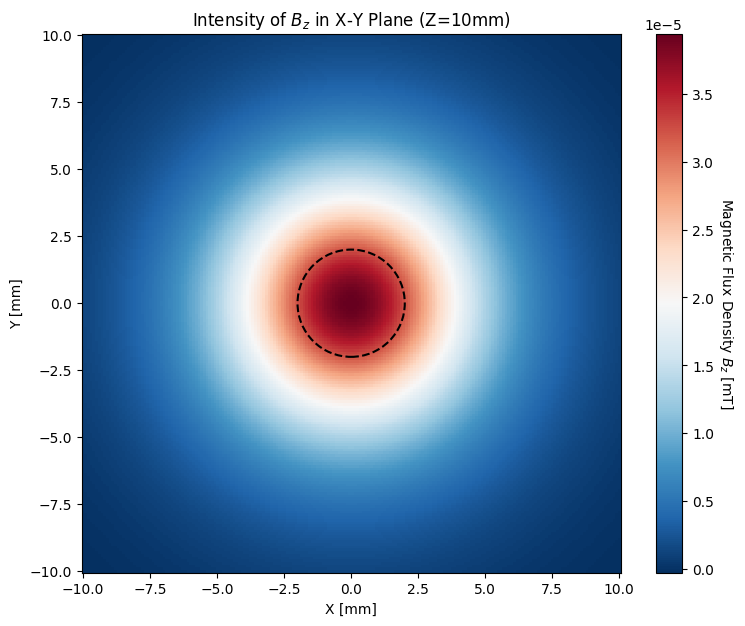

In [4]:
# 5. Visualization
fig, ax = plt.subplots(figsize=(9, 7))

# Create a heatmap using pcolormesh or imshow
# 'rdbu_r' is a great colormap for fields: Red for North (+), Blue for South (-)
mesh = ax.pcolormesh(xs, ys, Bz, cmap='RdBu_r', shading='auto')

# Add a colorbar to show the scale of mT
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Magnetic Flux Density $B_z$ [mT]', rotation=270, labelpad=15)

# Add a circle representing the magnet's physical edge
circle = plt.Circle((0, 0), 2, color='black', fill=False, lw=1.5, ls='--')
ax.add_patch(circle)

ax.set_title(f"Intensity of $B_z$ in X-Y Plane (Z={z_slice}mm)")
ax.set_xlabel("X [mm]")
ax.set_ylabel("Y [mm]")
ax.set_aspect('equal')

plt.show()

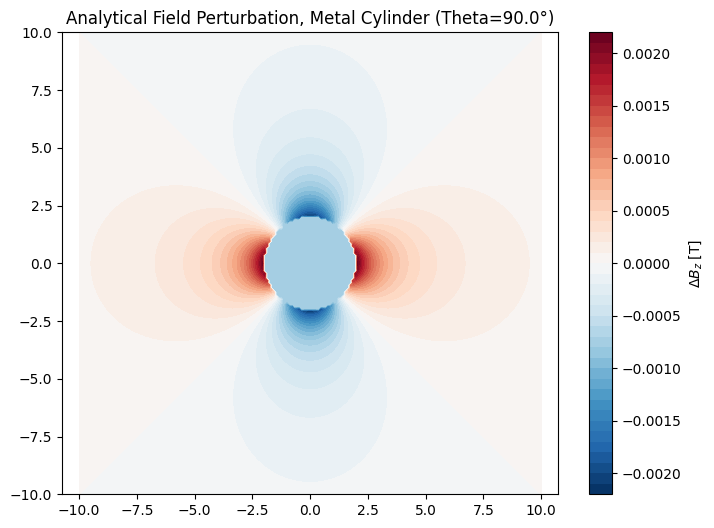

In [8]:
# simulate change in susceptibility

def cylinder_field_map(R, Phi, a, chi, theta, B0=1.5):
    """
    R: Radial distance from cylinder axis
    Phi: Angular position (0 is aligned with the projection of B0)
    a: Cylinder radius
    theta: Angle between B0 and cylinder axis (radians)
    """
    # Initialize field map
    delta_Bz = np.zeros_like(R)
    
    # Mask for inside vs outside
    inside = R <= a
    outside = R > a
    
    # Outside calculation
    delta_Bz[outside] = B0 * (chi/2) * (a/R[outside])**2 * (np.sin(theta)**2) * np.cos(2*Phi[outside])
    
    # Inside calculation (Uniform field)
    delta_Bz[inside] = B0 * (chi/6) * (3 * np.cos(theta)**2 - 1)
    
    return delta_Bz

# Grid Setup
x = np.linspace(-10, 10, 200)
y = np.linspace(-10, 10, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Phi = np.arctan2(Y, X)

# Parameters for a Stainless Steel-like rod
a = 2.0        # 2mm radius
chi = 3000e-6  # High susceptibility
theta = np.pi/2 # Perpendicular to B0

bz_map = cylinder_field_map(R, Phi, a, chi, theta)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, bz_map, levels=50, cmap='RdBu_r')
plt.colorbar(label='$\Delta B_z$ [T]')
plt.title(f"Analytical Field Perturbation, Metal Cylinder (Theta={np.degrees(theta)}°)")
plt.axis('equal')
plt.show()